<a href="https://colab.research.google.com/github/AnhNgoc201/Deeplearning/blob/main/Thuchanh_Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Fashion-MNIST: Denoising Autoencoder + CNN


## 1. Import thư viện

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load và chuẩn hóa dữ liệu

In [2]:
# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Tên các class
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Chuẩn hóa về [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Thêm chiều channel (28,28) → (28,28,1)
x_train = x_train[..., np.newaxis]
x_test  = x_test[...,  np.newaxis]

print('x_train shape:', x_train.shape)
print('x_test  shape:', x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test  shape: (10000, 28, 28, 1)


## 3. Tạo ảnh nhiễu (Gaussian Noise)

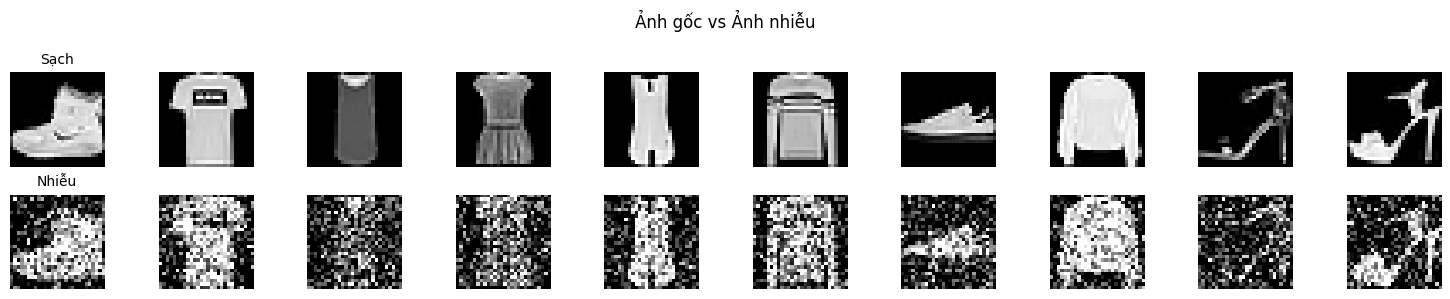

In [3]:
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy  = np.clip(x_test_noisy,  0., 1.)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Sạch', fontsize=10)
axes[1, 0].set_title('Nhiễu', fontsize=10)
plt.suptitle('Ảnh gốc vs Ảnh nhiễu', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Xây dựng Denoising Autoencoder


In [21]:
def build_autoencoder():
    inputs = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2,2), padding='same')(x)   # 14x14

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2), padding='same')(x)   # 7x7

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2,2), padding='same')(x)  # 4x4

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2,2))(x)   # 8x8

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)   # 16x16

    x = layers.Conv2D(32, (3,3), activation='relu')(x)   # 14x14
    x = layers.UpSampling2D((2,2))(x)   # 28x28

    decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

    autoencoder = keras.Model(inputs, decoded, name='denoising_autoencoder')
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_14 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## 5.Huấn luyện Autoencoder

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - loss: 0.0347 - val_loss: 0.0205
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0190 - val_loss: 0.0191
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0168 - val_loss: 0.0163
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0155 - val_loss: 0.0152
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0147 - val_loss: 0.0144
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0140 - val_loss: 0.0139
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0136 - val_loss: 0.0136
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0132 - val_loss: 0.0131
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0129 - val_loss: 0.0130
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0126 - val_loss: 0.0126
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0124 - val_loss: 0.0128
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━

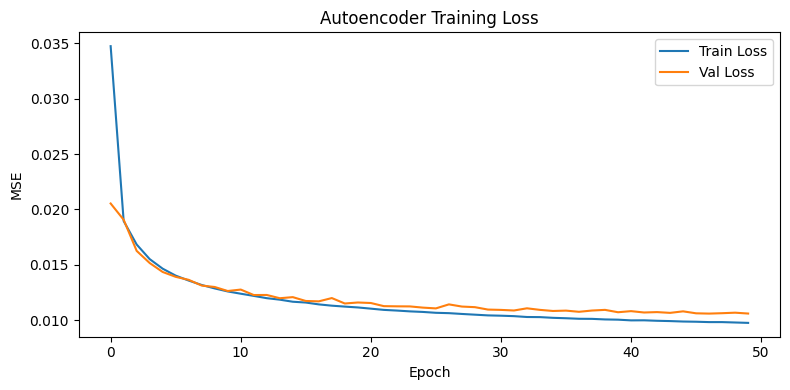

In [5]:
# Train Denoising Autoencoder
history_ae = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

# Plot loss
plt.figure(figsize=(8,4))
plt.plot(history_ae.history['loss'],     label='Train Loss')
plt.plot(history_ae.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

## 6.Kiểm tra kết quả khử nhiễu

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step


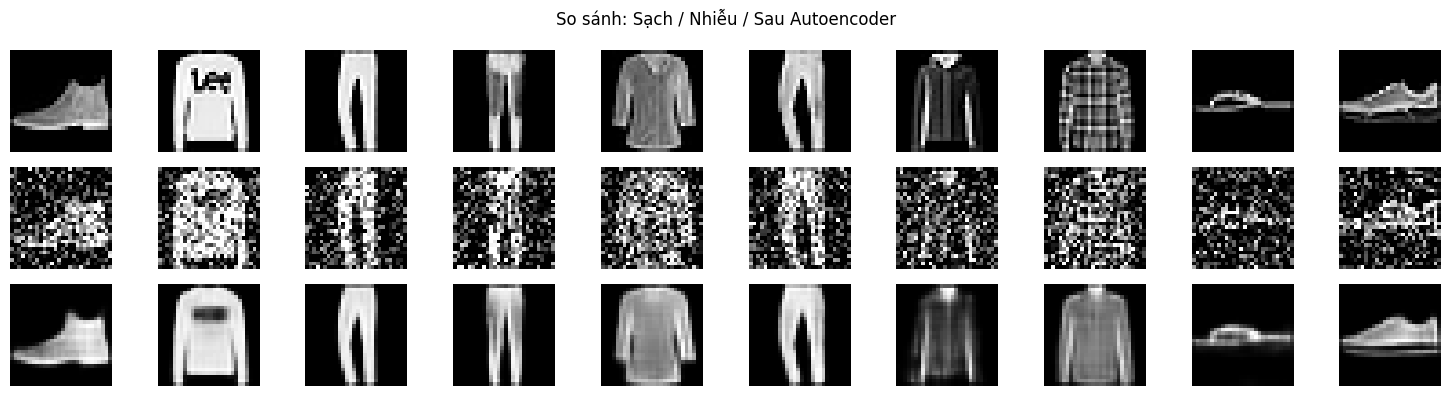

In [6]:
n = 10
clean_test = autoencoder.predict(x_test_noisy[:n])

fig, axes = plt.subplots(3, n, figsize=(15, 4))
for i in range(n):
    axes[0, i].imshow(x_test[i].squeeze(),       cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(clean_test[i].squeeze(),   cmap='gray'); axes[2, i].axis('off')

axes[0, 0].set_ylabel('Sạch',    fontsize=10)
axes[1, 0].set_ylabel('Nhiễu',   fontsize=10)
axes[2, 0].set_ylabel('Khử nhiễu', fontsize=10)
plt.suptitle('So sánh: Sạch / Nhiễu / Sau Autoencoder', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Xây dựng và Train CNN Classifier

In [7]:
def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='cnn_classifier')

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn = build_cnn()
cnn.summary()

Model: "cnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,026 (6.49 MB)

 Trainable params: 1,701,578 (6.49 MB)

 Non-trainable params: 448 (1.75 KB)

## 8.Tạo tập train cho CNN

In [8]:
print('Đang tạo dữ liệu train cho CNN...')
x_train_clean = autoencoder.predict(x_train_noisy, batch_size=256)
x_test_clean  = autoencoder.predict(x_test_noisy,  batch_size=256)
print('Done!')

# Train CNN trên ảnh đã khử nhiễu
history_cnn = cnn.fit(
    x_train_clean, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(x_test_clean, y_test),
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
)

Đang tạo dữ liệu train cho CNN...
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Done!
Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.7657 - loss: 0.6609 - val_accuracy: 0.3135 - val_loss: 2.1651 - learning_rate: 0.0010
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8130 - loss: 0.5088 - val_accuracy: 0.7912 - val_loss: 0.5776 - learning_rate: 0.0010
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8258 - loss: 0.4708 - val_accuracy: 0.8316 - val_loss: 0.4540 - learning_rate: 0.0010
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8328 - loss: 0.4492 - val_accuracy: 0.8409 - val_loss: 0.4318 - learning_rate: 0.0010
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8403 - loss: 0.4320 - val_accuracy: 0.8424 - val_loss: 0.4324 - learning_rate: 0.0010
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8449 - loss: 0.4143 - val_accuracy: 0.8410 - v

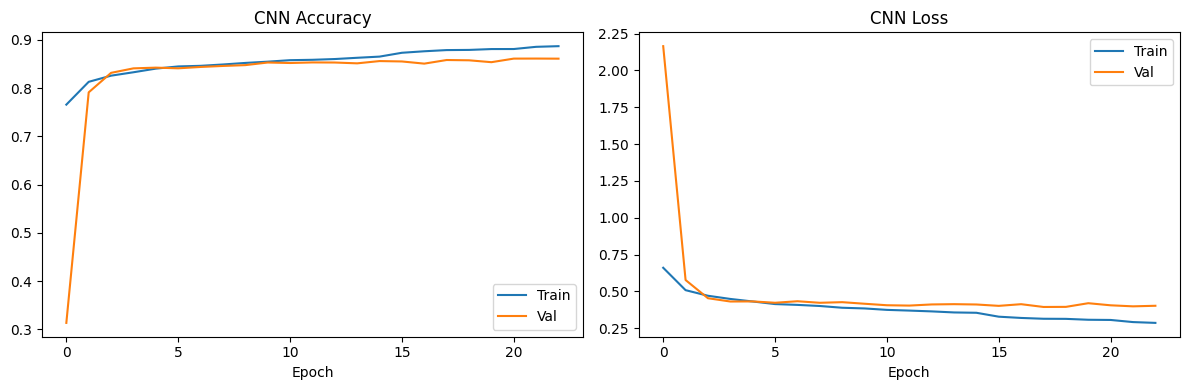

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_cnn.history['accuracy'],     label='Train')
ax1.plot(history_cnn.history['val_accuracy'], label='Val')
ax1.set_title('CNN Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_cnn.history['loss'],     label='Train')
ax2.plot(history_cnn.history['val_loss'], label='Val')
ax2.set_title('CNN Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Đánh giá toàn bộ Pipeline

In [10]:
# Đánh giá trên test set
loss, acc = cnn.evaluate(x_test_clean, y_test, verbose=0)
print(f'Test Accuracy (noisy → autoencoder → CNN): {acc*100:.2f}%')

# So sánh: CNN trực tiếp trên ảnh sạch
loss2, acc2 = cnn.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy (ảnh sạch → CNN trực tiếp):  {acc2*100:.2f}%')

Test Accuracy (noisy → autoencoder → CNN): 85.82%
Test Accuracy (ảnh sạch → CNN trực tiếp):  88.20%


In [17]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = np.argmax(cnn.predict(x_test_clean), axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))

print(classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.80      0.80      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.73      0.76      0.75      1000
       Dress       0.87      0.86      0.87      1000
        Coat       0.78      0.75      0.76      1000
      Sandal       0.96      0.93      0.95      1000
       Shirt       0.63      0.65      0.64      1000
     Sneaker       0.90      0.94      0.92      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



<Figure size 1000x800 with 0 Axes>

## 7. Test với ảnh thật từ máy tính

Saving bag.jpg to bag.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


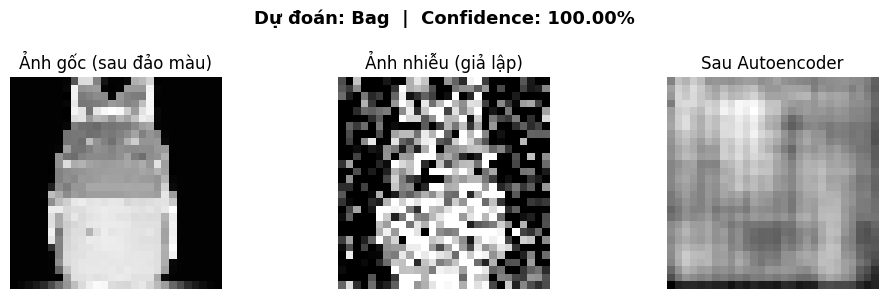


Top 3 dự đoán:
  1. Bag             100.00%
  2. Trouser         0.00%
  3. Shirt           0.00%


In [27]:
from google.colab import files

# Upload ảnh
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Đọc & xử lý ảnh
img = image.load_img(img_path, color_mode='grayscale', target_size=(28, 28))
img_array = image.img_to_array(img).astype('float32') / 255.0

# Đảo màu nếu cần (ảnh thật thường: vật thể tối, nền sáng)
# Fashion-MNIST: vật thể TRẮNG trên nền ĐEN
img_array = 1.0 - img_array

img_array = np.expand_dims(img_array, axis=0)

# Pipeline
clean_img  = autoencoder.predict(img_array)
prediction = cnn.predict(clean_img)

label      = np.argmax(prediction)
confidence = np.max(prediction)

# Hiển thị kết quả
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(img_array[0].squeeze(), cmap='gray')
axes[0].set_title('Ảnh gốc (sau đảo màu)')
axes[0].axis('off')

# Thêm nhiễu
img_noisy = np.clip(
    img_array + 0.4 * np.random.normal(size=img_array.shape), 0., 1.
)
clean_from_noisy = autoencoder.predict(img_noisy)

axes[1].imshow(img_noisy[0].squeeze(), cmap='gray')
axes[1].set_title('Ảnh nhiễu (giả lập)')
axes[1].axis('off')

axes[2].imshow(clean_img[0].squeeze(), cmap='gray')
axes[2].set_title(f'Sau Autoencoder')
axes[2].axis('off')

plt.suptitle(
    f'Dự đoán: {class_names[label]}  |  Confidence: {confidence*100:.2f}%',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('\nTop 3 dự đoán:')
top3 = np.argsort(prediction[0])[::-1][:3]
for i, idx in enumerate(top3):
    print(f'  {i+1}. {class_names[idx]:15s} {prediction[0][idx]*100:.2f}%')